In [1]:
import shap
import torch
from src import *
from src.autoencoder import *
from src.modelling import *


### load data for ae extension

In [2]:
sdo = setDisplayOptions()
utls = trainUtils()
# ---
root = Path("./data/")
imgs = Path("./imgs.bak/")
imgs.mkdir(exist_ok=True)


In [3]:
schema = yamlLoader("./schema/modelling.yaml")
data = gpd.read_file(f"{root}/tcbGridFeatures-TSAE29.gpkg")
# ---
f_outputs = schema["targets"]
data[f_outputs] = data[f_outputs].astype(int)
# ---
printFeatureCardinality(data)


data.shape=(19474, 32) ... 0.00GB
[int] id                 : 19474   [int] isBikeStation      : 2       [int] nHousing           : 173  
[int] nJob               : 312     [float] popTotal         : 3536    [float] avgIncome        : 1208 
[int] nRetail            : 11      [int] nOffice            : 4       [int] nSchool            : 6    
[float] distCBD          : 19345   [float] distRetail       : 17236   [float] distOffice       : 18726
[float] distSchool       : 18406   [float] Slope            : 1871    [float] Elevation        : 14379
[int] nStreet            : 52      [int] nJunction          : 16      [int] nMotorLane         : 828  
[int] nBikeLane          : 1044    [float] cyclingFlow      : 637     [int] peopleFlow         : 1528 
[int] nBusStop           : 13      [int] nBusLine           : 24      [float] distBusStop      : 17440
[float] transitFlow      : 1961    [float] cyclingFlow.mean : 1974    [float] cyclingFlow.max  : 378  
[float] peopleFlow.mean  : 7612    [flo

In [4]:
n_existing = data["isBikeStation"].sum().item()
n_candidates = len(data) - n_existing
print(f"{n_existing=}, {n_candidates=} > imbalance ratio: {n_candidates / n_existing:.4f}")


n_existing=68, n_candidates=19406 > imbalance ratio: 285.3824


### init dataloader and model


In [5]:
r_generator, r_worker = setReproducibility(seed=17711)
to = tabularDataloader(data, f_outputs=f_outputs, normalised=True, pct_valid=0.2)


to.train (X,y): (15580, 29) (15580, 2)
to.valid (X,y): (3894, 29) (3894, 2)


In [6]:
cfg = configAE(
    n_layers=2,
    embed_dim=8,
    wf_lambda=0.15,
    hidden_dim=16,
    exp_scaling=True,
    save_model=True,
    supervised=True,
    # ---
    n_features=len(to.x_names),  # type:ignore
    model_dir="./models",
)
cfg.model_name = utls.getModelName(cfg)


In [9]:
# init ae dataloader and model; sanity check input layer
dls = dataloaderAE(to, cfg, worker_init_fn=r_worker, generator=r_generator)
model = hybridAutoEncoder(cfg) if cfg.supervised else baseAutoEncoder(cfg)
print("input layer:", list(model.encoder.modules())[1])


feature noise augmentation layer added to autoencoder
hybridAutoEncoder initialised with 3.46K parameters
supervised classification head added with 0.16K additional parameters
input layer: Linear(in_features=29, out_features=32, bias=True)


### train model and extract encodings/logits

In [ ]:
metrics = trainAE(dls.dataloaders(), model, cfg)
prefix = f"{model.model_dir}/{model.model_tag}"

if cfg.save_model:
    utls.saveTrainingConfig(cfg, fp=f"{prefix}/config.json", verbose=True)
    utls.saveTrainingLog(metrics, fp=f"{prefix}/metrics.json")
    utls.plotTrainingLosses(metrics, cfg, save=f"{prefix}/metrics.png")


training:  49%|████▊     | 497/1024 [01:36<01:42,  5.16it/s, train=0.087, valid=0.0973] 


early stopping criterion met; best validation loss: 0.0971
model loaded from models/haeL2H16eE8-12021541/model.pth
training configuration saved to ./models/haeL2H16eE8-12021541/config.json


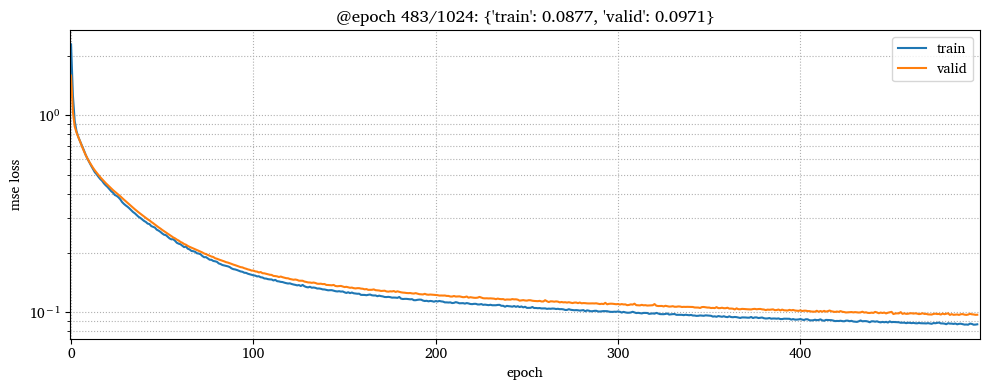

In [ ]:
utls.plotTrainingLosses(metrics, cfg)


In [22]:
# load best model from previous training
model.model_tag = "haeL2H16eE8-12021541"  # update with actual model tag from training log
model.load()
prefix = f"{model.model_dir}/{model.model_tag}"


model loaded from models/haeL2H16eE8-12021541/model.pth


extracting encodings + logits with internal dataloader of batch size 512...
self.encodings.shape=(19474, 8) + self.logits.shape=(19474,) > self.ids.shape=(19474,)
z-score normalisation applied to encoded features
HEI: Doing sanity checks ... No issues?? True


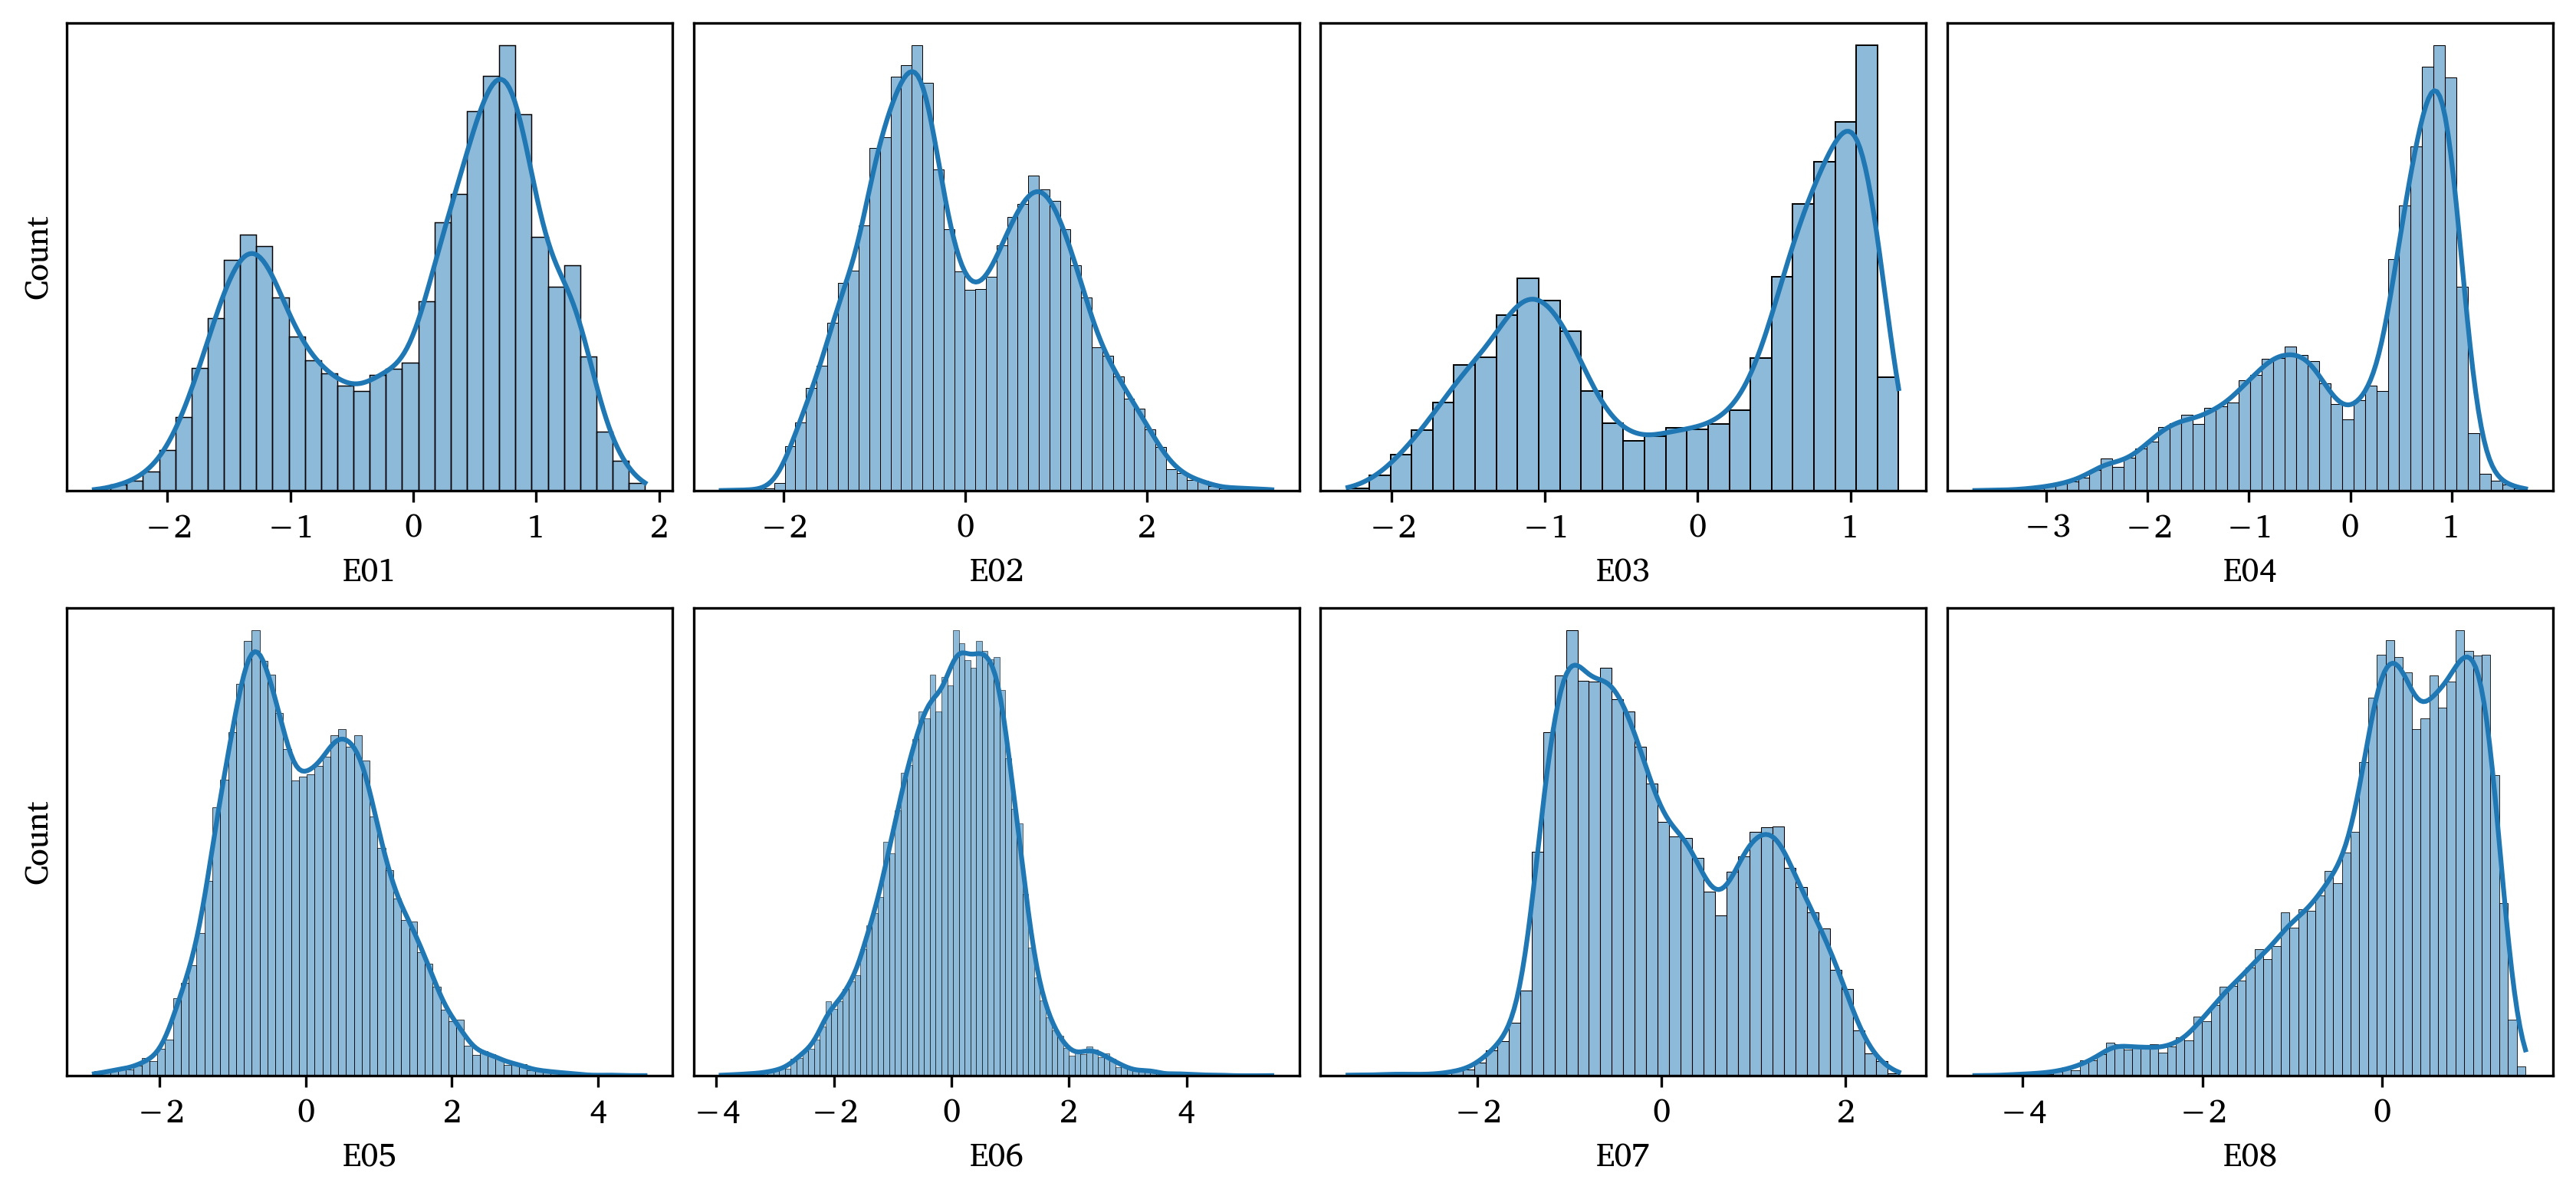

In [23]:
extractor = featureExtractor(model, to)
efdf = extractor.encodedFeatures(zscore=True, l2norm=False)
efdf.columns = ["id"] + [f"E{i + 1:02}" for i in range(efdf.shape[1] - 1)]
peekNumerical(efdf.drop(columns="id"), n_cols=4, yticks=False)


In [24]:
fn = f"{prefix}/correlation.png"
featureClustering(efdf.drop(columns="id"), figsize=(4, 1.75), font_size=8, save=fn)


### cluster analysis with encoded features

In [25]:
fc = baseClusterAnalysis(efdf)
results = fc.runAnalysis(best_k=5)
gridClusters = fc.saveResults()


running feature clustering analysis...
using provided cluster size for computing k-means...


analysis complete. optimal clusters: 5 (silhouette: 0.253)


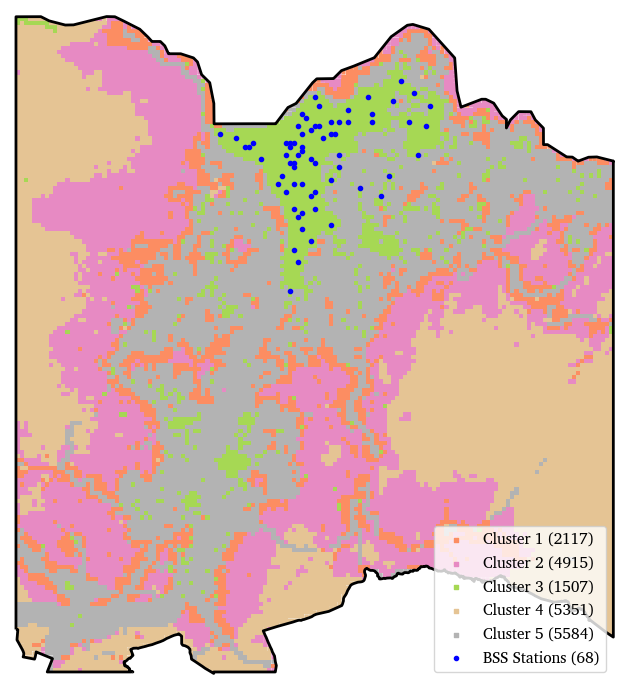

In [26]:
fn, title = f"{prefix}/clustermap.png", utls.getPlotTitle(cfg)
m = staticMultiClusterMap(data, gridClusters, fn=fn, title=None)


### shap explanation

In [27]:
def df2tensor(df: pd.DataFrame, n: int) -> torch.Tensor:
    df = df.copy().sample(n=n, random_state=17711)
    return torch.tensor(df.values, dtype=torch.float32).to(model.device)


def predictor(data: pd.DataFrame) -> np.ndarray:
    """wrapper around model to return predictions as numpy array for shap"""
    tensor = torch.tensor(data.values, dtype=torch.float32).to(model.device)
    with torch.no_grad():
        return model(tensor, encode=True).detach().cpu().numpy()  # return encodings


In [28]:
aoiFeatures = list(to.x_names)  # type:ignore
aeClasses = [c for c in efdf.columns if c != "id"]

X_train, X_valid = to.train.xs, to.valid.xs
masker = X_train.copy().sample(n=8192)
inputs = X_valid.copy().sample(n=2048)


In [29]:
shapPE = shap.PermutationExplainer(predictor, masker=masker, seed=17711, feature_names=aoiFeatures)
with pipeCellOutput():
    resultPE: shap.Explanation = shapPE(inputs)  # type:ignore
print(f"{resultPE.shape=}")  # [n_samples, n_features, n_outputs]

# reorganise to list of `[n_samples, n_features] * n_outputs` shap values for plotting
shapvaluesPE = [resultPE[..., i].values for i in range(len(aeClasses))]
fn = f"{prefix}/shapValuesPE.npy"
np.save(fn, shapvaluesPE)


resultPE.shape=(2048, 29, 8)


In [30]:
# [NOTE] load precomputed shap values for plotting
fn = f"{prefix}/shapValuesPE.npy"
shapvaluesPE = np.load(fn, allow_pickle=True)
print(f"{shapvaluesPE.shape=}")
shapvaluesPE = [shapvaluesPE[i] for i in range(len(aeClasses))]  # ensure correct order


shapvaluesPE.shape=(8, 2048, 29)


In [31]:
kwargs = {"features": inputs, "class_names": aeClasses, "rng": 17711, "max_display": 21}
cmap = slicePalette("tab10", n=len(aeClasses))
shap.summary_plot(shapvaluesPE, **kwargs, plot_size=(5, 5.15), color=cmap, show=False)

plt.yticks(fontsize=9)
plt.xticks(fontsize=9)
plt.xlabel("mean(|SHAP value|)", fontsize=10)
plt.tight_layout(pad=0)
plt.legend(
    fontsize=9,
    ncols=1,
    handlelength=0.7,  # width of color swatch (default ~2.0)
    handleheight=0.6,  # height of color swatch (default ~0.7)
    handletextpad=0.4,  # gap between swatch and its label (default ~0.8)
    columnspacing=0.8,  # horizontal space between entries (default ~2.0)
)

fn = f"{prefix}/shapSummary.png"
plt.savefig(fn, bbox_inches="tight", dpi=300)
plt.close()
print(f"shap summary plot saved to ./{fn}")


shap summary plot saved to ././models/haeL2H16eE8-12021541/shapSummary.png


### export data for webapp


In [32]:
def checks(src: gpd.GeoDataFrame):
    assert sanityCheck(src), "!!!"
    assert len(src) == len(data), "!!!"
    assert str(src.crs) == str(data.crs) == "EPSG:25833", "!!!"


In [33]:
f_grid = ["id", "isBikeStation", "geometry"]
gdf = data[f_grid].copy()
checks(gdf)
gdf2csv(gdf, f"{root}/tcbGridFeatures-TSAE29.csv")


HEI: Doing sanity checks ... No issues?? True


In [34]:
dsubTO = data[f_grid].merge(to.items, on=["id", "isBikeStation"], how="left").copy()
checks(dsubTO)
gdf2csv(dsubTO, f"{root}/TO-SpatialFeatures.csv")


HEI: Doing sanity checks ... No issues?? True


In [35]:
# extract encodings with zscore and l2 normalisation for cosine similarity
efdfAE = getEncodedFeatures(model, to, zscore=True, l2norm=True)
dsubAE = data[f_grid].merge(efdfAE, on="id", how="left").copy()
checks(dsubAE)
gdf2csv(dsubAE, f"{root}/AE-CosineEncodings.csv")


extracting encodings + logits with internal dataloader of batch size 512...
self.encodings.shape=(19474, 8) + self.logits.shape=(19474,) > self.ids.shape=(19474,)
z-score normalisation applied to encoded features
l2-normalisation applied to encoded samples
HEI: Doing sanity checks ... No issues?? True
HEI: Doing sanity checks ... No issues?? True


In [36]:
# extract encodings with only zorder normalisation for euclidean similarity
efdfZO = getEncodedFeatures(model, to, zscore=True, l2norm=False)
dsubZO = data[f_grid].merge(efdfZO, on="id", how="left").copy()
checks(dsubZO)
gdf2csv(dsubZO, f"{root}/AE-EuclideanEncodings.csv")


extracting encodings + logits with internal dataloader of batch size 512...
self.encodings.shape=(19474, 8) + self.logits.shape=(19474,) > self.ids.shape=(19474,)
z-score normalisation applied to encoded features
HEI: Doing sanity checks ... No issues?? True
HEI: Doing sanity checks ... No issues?? True


### end